In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path

from scipy import stats
from scipy.stats import norm

warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'figure.dpi': 150,
})

SAMPLE_SIZES = [2, 5, 30, 100]
N_SIM = 5000
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
ALPHA = 0.65

In [3]:
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Rozkład bazowy: Wykładniczy(λ=1)

Celowo silnie asymetryczny, żeby CTG było widoczne

In [4]:
DIST_NAME = "Wykładniczy(λ=1)"

dist = stats.expon(scale=1)

TRUE_MEAN = dist.mean()
TRUE_VAR = dist.var()
TRUE_MEAN_X2 = dist.moment(2)
TRUE_VAR_X2 = dist.moment(4) - dist.moment(2)**2

print(f"Rozkład: {DIST_NAME}")
print(f"Prawdziwa wartość oczekiwana: {TRUE_MEAN:.2f}")
print(f"Prawdziwa wariancja: {TRUE_VAR:.2f}")
print(f"Prawdziwa wartość oczekiwana X^2: {TRUE_MEAN_X2:.2f}")
print(f"Prawdziwa wariancja X^2: {TRUE_VAR_X2:.2f}")

Rozkład: Wykładniczy(λ=1)
Prawdziwa wartość oczekiwana: 1.00
Prawdziwa wariancja: 1.00
Prawdziwa wartość oczekiwana X^2: 2.00
Prawdziwa wariancja X^2: 20.00


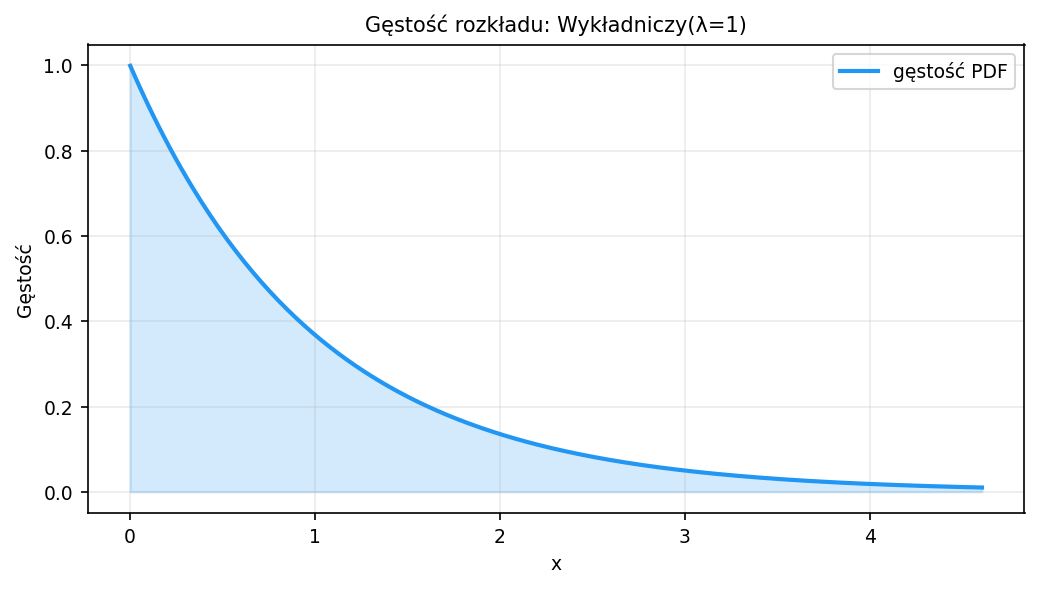

In [5]:
x = np.linspace(dist.ppf(0.001), dist.ppf(0.99), 300)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, dist.pdf(x), color='#2196F3', lw=2, label='gęstość PDF')
ax.fill_between(x, dist.pdf(x), color='#2196F3', alpha=0.2)
ax.set_title(f"Gęstość rozkładu: {DIST_NAME}")
ax.set_xlabel('x')
ax.set_ylabel('Gęstość')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / f"{DIST_NAME.replace(' ', '_')}_pdf.pdf")
plt.show()
plt.close()

In [6]:
def simulate_means(n, n_sim=N_SIM):
    samples = dist.rvs(size=(n_sim, n))

    xbar = samples.mean(axis=1)
    xbar_sq = (samples**2).mean(axis=1)

    return xbar, xbar_sq

In [7]:
def standardize(values, true_mean, true_var, n):
    return np.sqrt(n) * (values - true_mean) / np.sqrt(true_var)

#  WYKRES 1: Histogramy + krzywa normalna

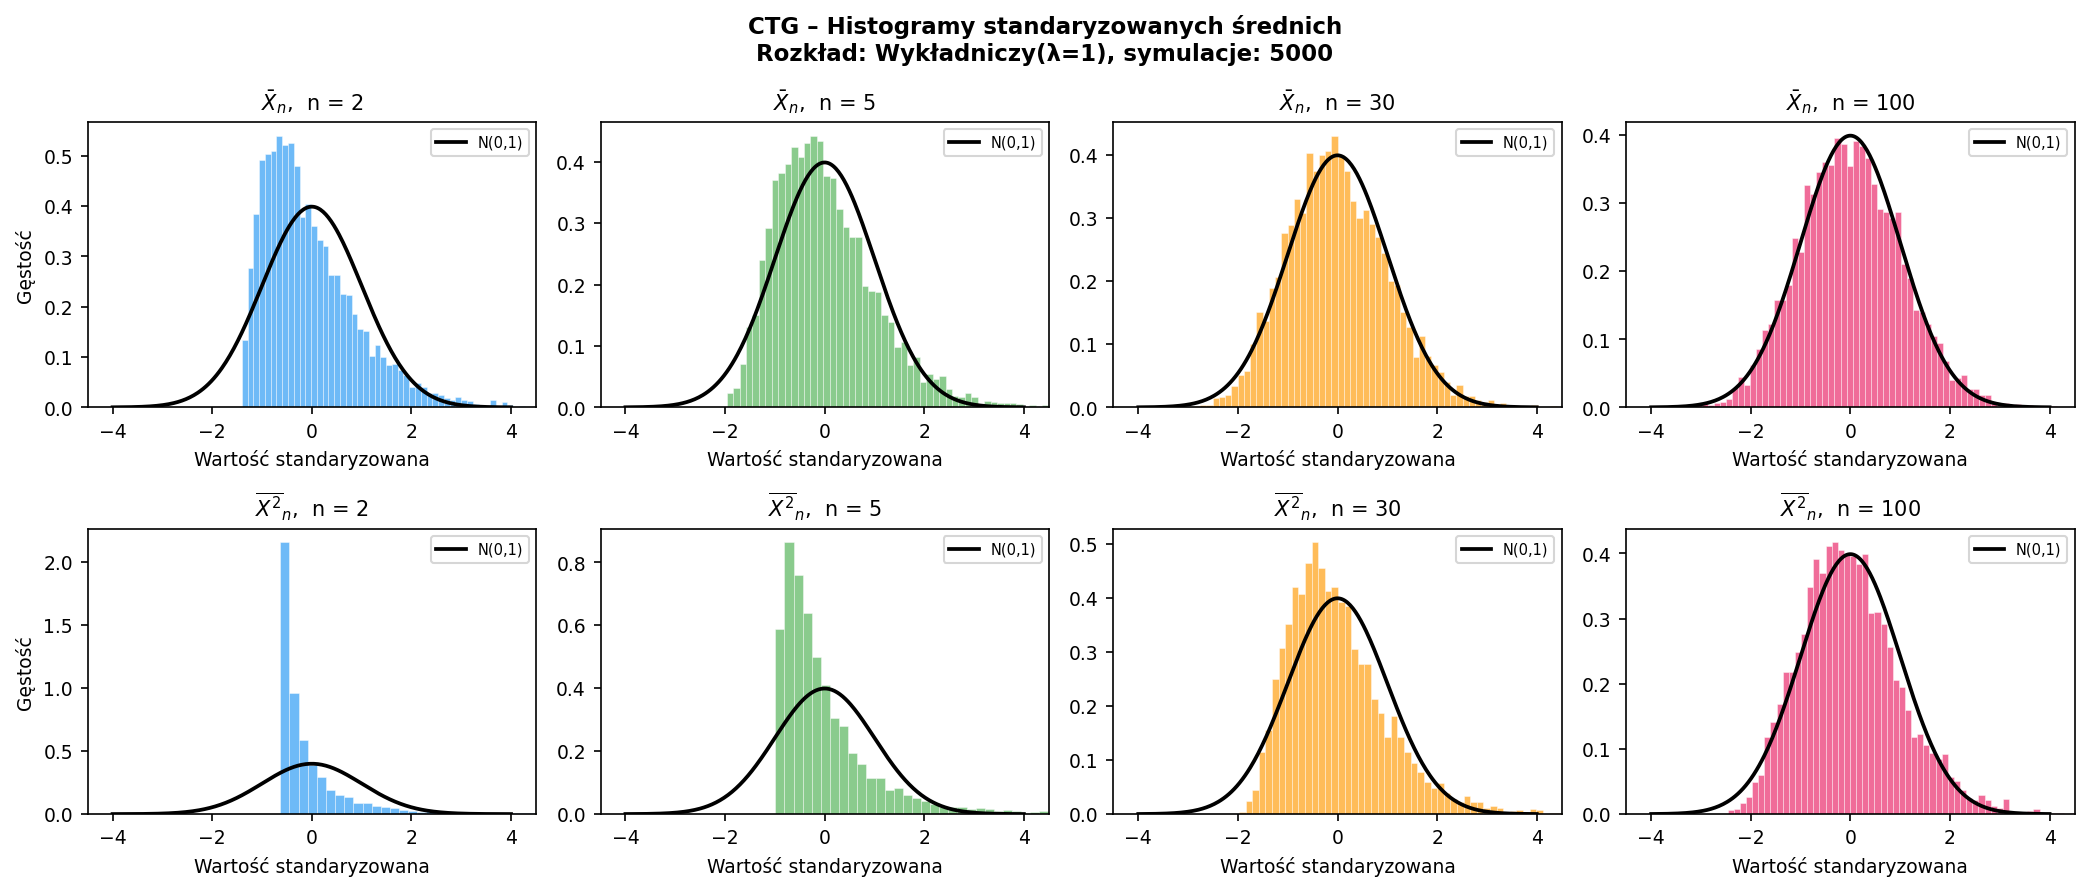

In [8]:
fig1, axes = plt.subplots(2, len(SAMPLE_SIZES), figsize=(14, 6), constrained_layout=True)
fig1.suptitle(
    f"CTG – Histogramy standaryzowanych średnich\n"
    f"Rozkład: {DIST_NAME}, symulacje: {N_SIM}",
    fontsize=11, fontweight='bold'
)

x_range = np.linspace(-4, 4, 300)
normal_pdf = norm.pdf(x_range)

for col, n in enumerate(SAMPLE_SIZES):
    xbar, xbar_sq = simulate_means(n)

    z1 = standardize(xbar, TRUE_MEAN, TRUE_VAR, n)
    z2 = standardize(xbar_sq, TRUE_MEAN_X2, TRUE_VAR_X2, n)

    for row, (z, label) in enumerate([(z1, r"$\bar{X}_n$"), (z2, r"$\overline{X^2}_n$")]):
        ax = axes[row, col]
        ax.hist(z, bins=60, density=True, color=COLORS[col], alpha=ALPHA, edgecolor='white', linewidth=0.3)
        ax.plot(x_range, normal_pdf, 'k-', lw=1.8, label='N(0,1)')
        ax.set_title(f"{label},  n = {n}")
        ax.set_xlim(-4.5, 4.5)
        ax.set_xlabel("Wartość standaryzowana")

        if col == 0:
            ax.set_ylabel("Gęstość")

        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
fig1.savefig(IMAGES_DIR / "fig1_histogramy.pdf", bbox_inches='tight')
plt.close(fig1)

#  WYKRES 2: Estymatory jądrowe (KDE)

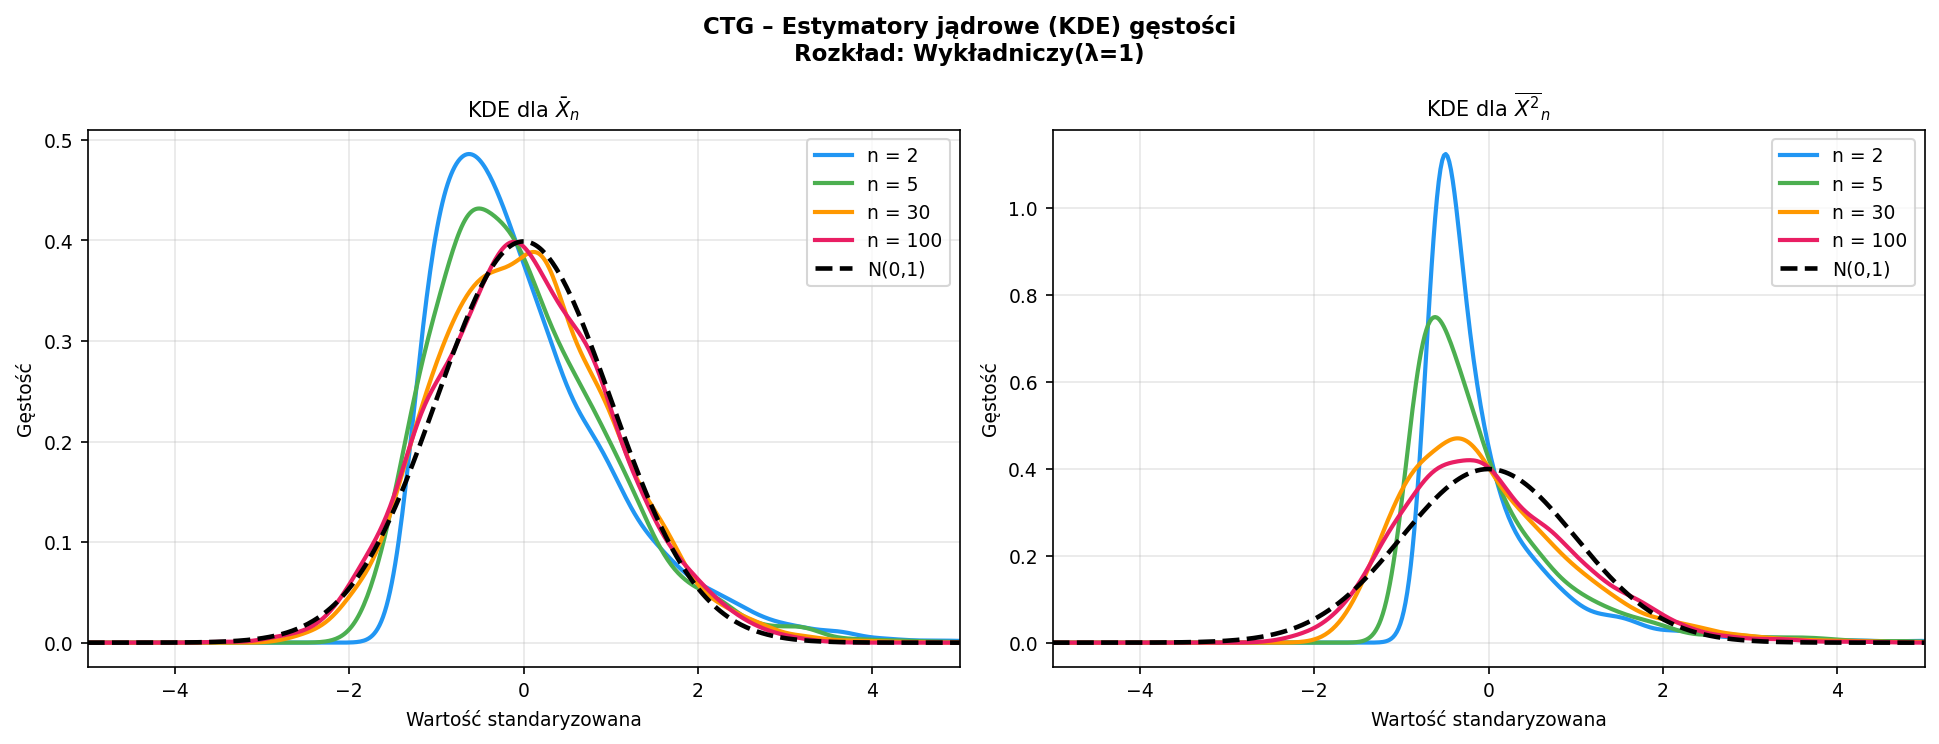

In [ ]:
fig2, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

fig2.suptitle(
    f"CTG – Estymatory jądrowe (KDE) gęstości\nRozkład: {DIST_NAME}",
    fontsize=11, fontweight='bold'
)

x_range = np.linspace(-5, 5, 500)

for ax, (true_mean, true_var, label) in zip(
    axes,
    [(TRUE_MEAN, TRUE_VAR, r"$\bar{X}_n$"), (TRUE_MEAN_X2, TRUE_VAR_X2, r"$\overline{X^2}_n$")]
):
    for col, n in enumerate(SAMPLE_SIZES):
        xbar, xbar_sq = simulate_means(n)

        z = standardize(
            xbar if label == r"$\bar{X}_n$" else xbar_sq,
            true_mean, true_var, n
        )

        kde = stats.gaussian_kde(z, bw_method='silverman')

        ax.plot(x_range, kde(x_range), color=COLORS[col], lw=2, label=f"n = {n}")

    ax.plot(x_range, norm.pdf(x_range), 'k--', lw=2.2, label='N(0,1)')
    ax.set_title(f"KDE dla {label}")
    ax.set_xlabel("Wartość standaryzowana")
    ax.set_ylabel("Gęstość")
    ax.set_xlim(-5, 5)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
fig2.savefig(IMAGES_DIR / "fig2_kde.pdf", bbox_inches='tight')
plt.close(fig2)

#  WYKRES 3: Dystrybuanty empiryczne vs normalna (ECDF)

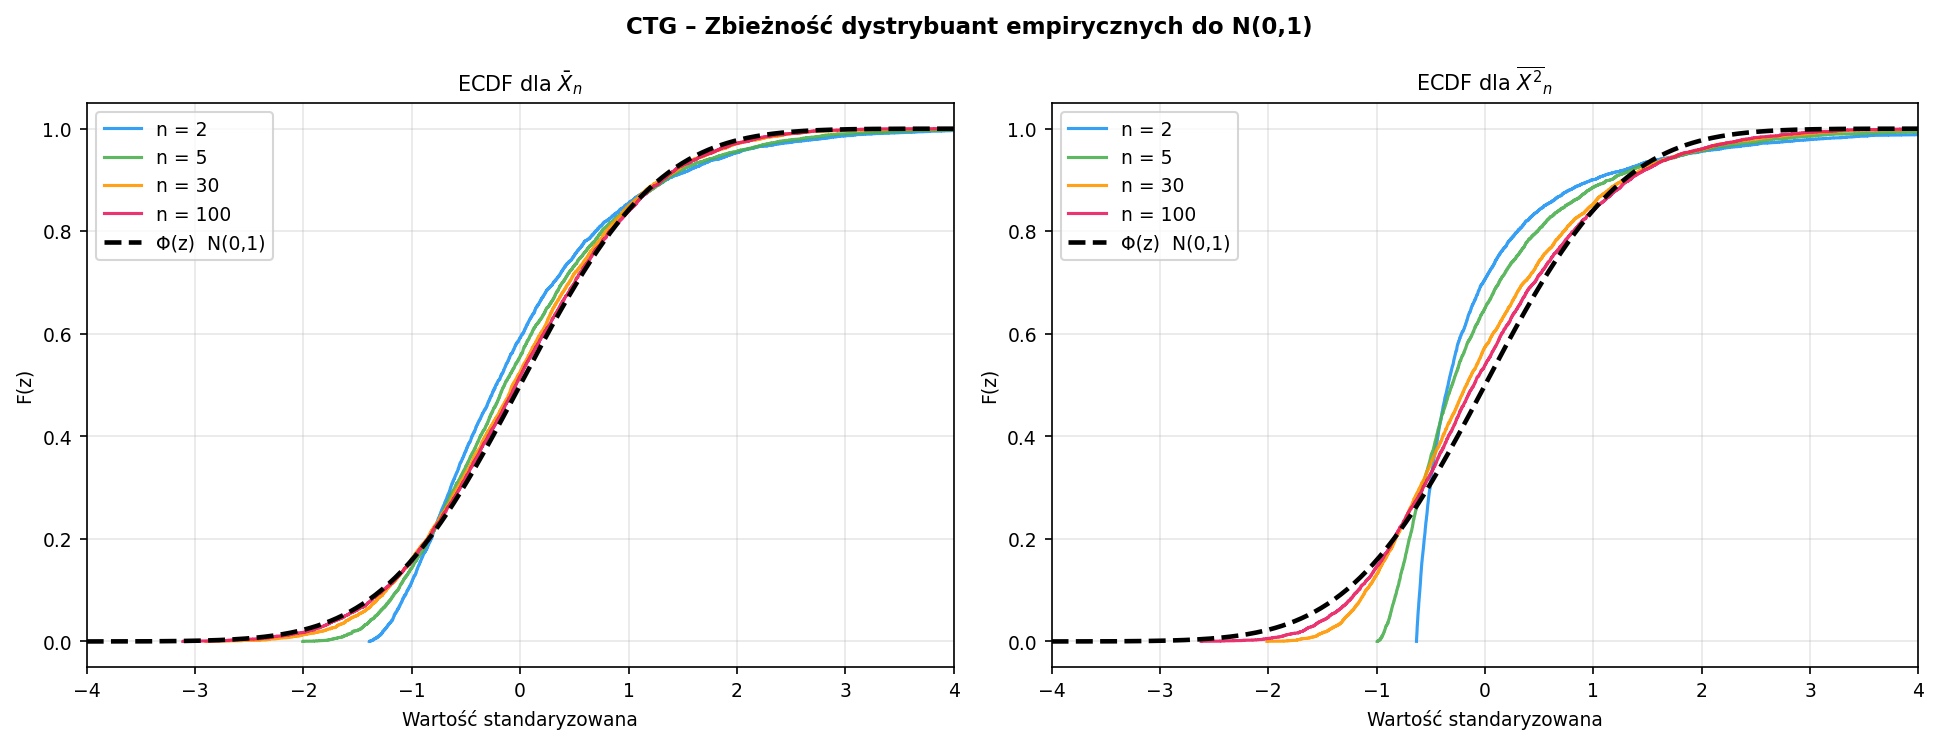

In [ ]:
fig3, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig3.suptitle(
    "CTG – Zbieżność dystrybuant empirycznych do N(0,1)",
    fontsize=11, fontweight='bold'
)

x_range = np.linspace(-4, 4, 400)

for ax, (true_mean, true_var, label) in zip(
    axes,
    [(TRUE_MEAN, TRUE_VAR, r"$\bar{X}_n$"), (TRUE_MEAN_X2, TRUE_VAR_X2, r"$\overline{X^2}_n$")]
):
    for col, n in enumerate(SAMPLE_SIZES):
        xbar, xbar_sq = simulate_means(n)

        z = standardize(
            xbar if label == r"$\bar{X}_n$" else xbar_sq,
            true_mean, true_var, n
        )

        z_sorted = np.sort(z)
        ecdf = np.arange(1, len(z_sorted) + 1) / len(z_sorted)

        ax.step(z_sorted, ecdf, color=COLORS[col], lw=1.5, alpha=0.9, label=f"n = {n}")

    ax.plot(x_range, norm.cdf(x_range), 'k--', lw=2.2, label='Φ(z)  N(0,1)')
    ax.set_title(f"ECDF dla {label}")
    ax.set_xlabel("Wartość standaryzowana")
    ax.set_ylabel("F(z)")
    ax.set_xlim(-4, 4)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
fig3.savefig(IMAGES_DIR / "fig3_ecdf.pdf", bbox_inches='tight')
plt.close(fig3)

#  WYKRES 4: Wykresy Q-Q

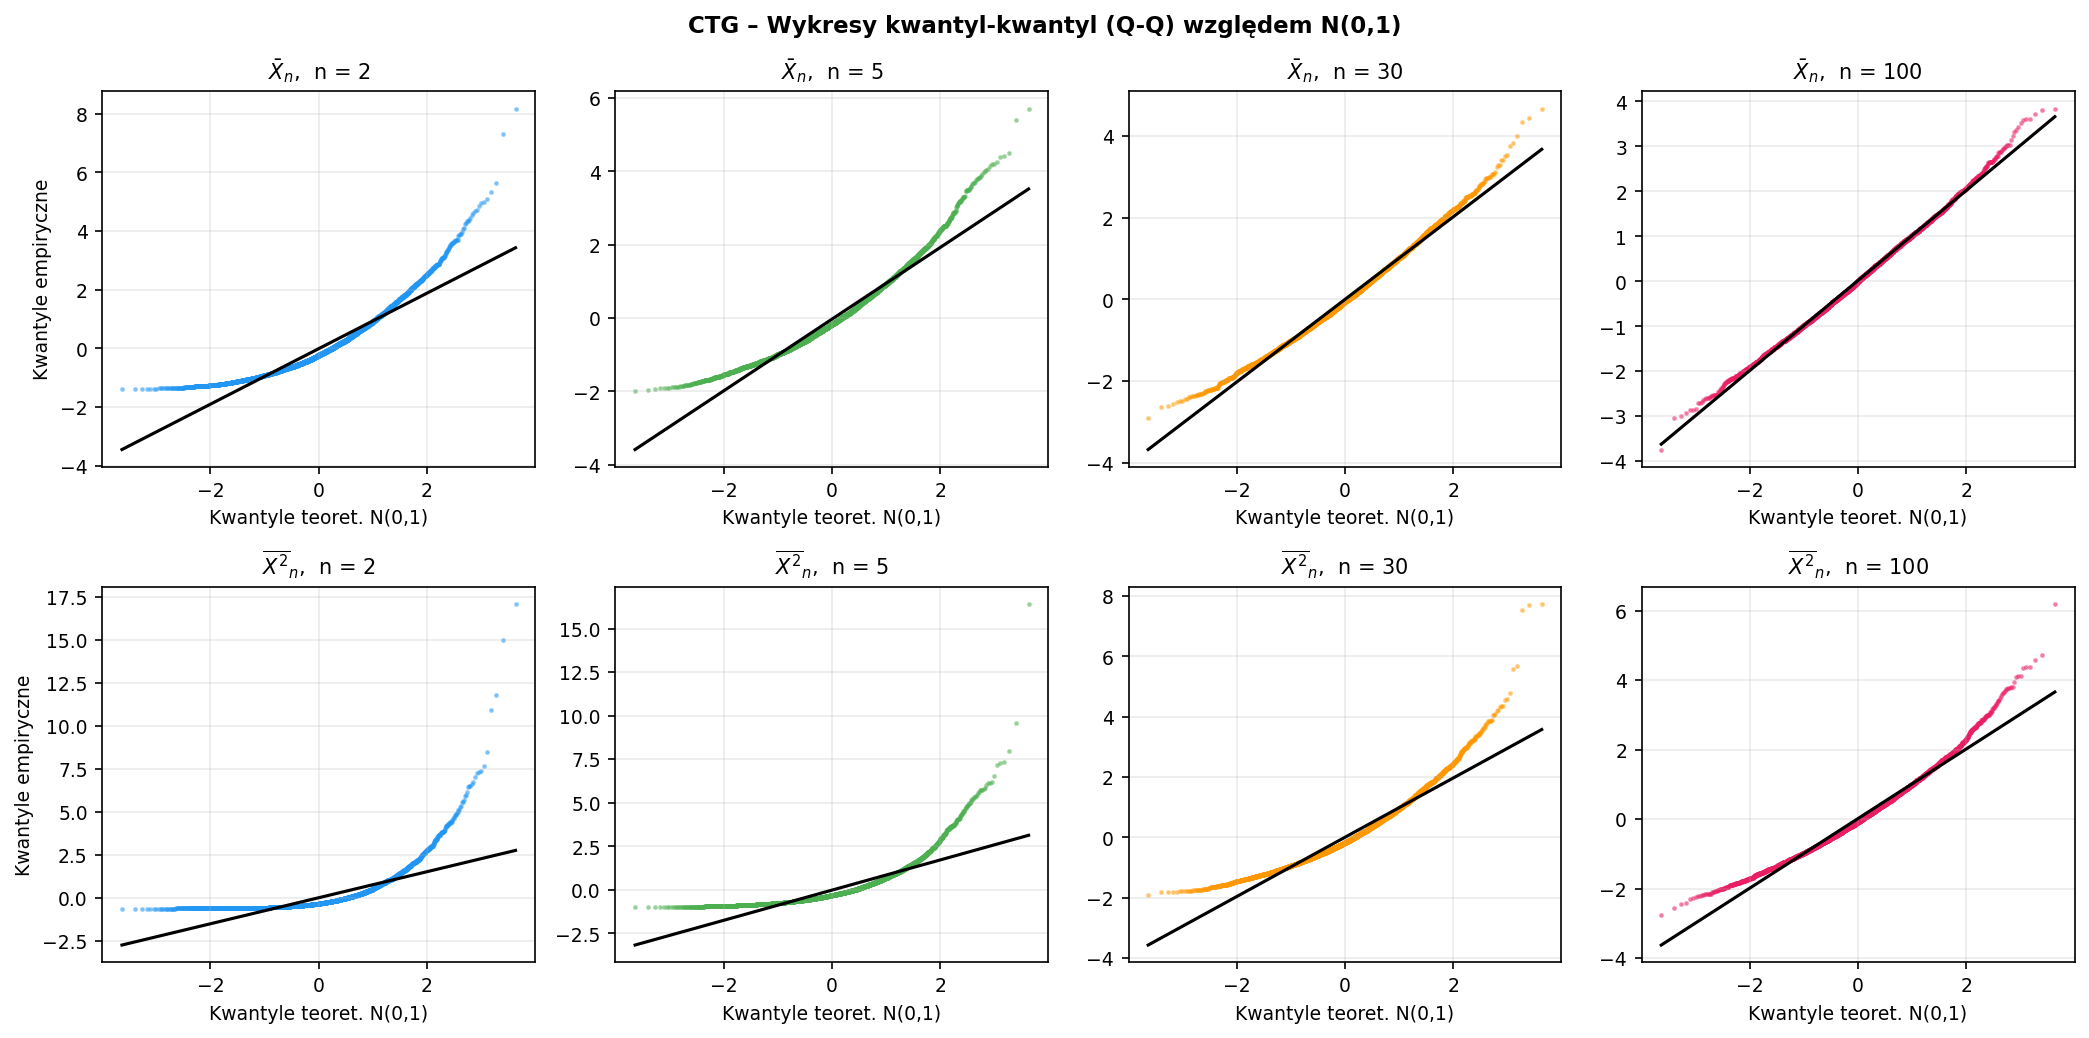

In [11]:
fig4, axes = plt.subplots(2, len(SAMPLE_SIZES), figsize=(14, 7), constrained_layout=True)
fig4.suptitle(
    "CTG – Wykresy kwantyl-kwantyl (Q-Q) względem N(0,1)",
    fontsize=11, fontweight='bold'
)

for col, n in enumerate(SAMPLE_SIZES):
    xbar, xbar_sq = simulate_means(n)

    z1 = standardize(xbar, TRUE_MEAN, TRUE_VAR, n)
    z2 = standardize(xbar_sq, TRUE_MEAN_X2, TRUE_VAR_X2, n)

    for row, (z, lbl) in enumerate([(z1, r"$\bar{X}_n$"), (z2, r"$\overline{X^2}_n$")]):
        ax = axes[row, col]

        (osq, osl), (slope, intercept, _) = stats.probplot(z, dist='norm')

        ax.scatter(osq, osl, s=2, color=COLORS[col], alpha=0.4)

        xlim = np.array([osq.min(), osq.max()])

        ax.plot(xlim, slope * xlim + intercept, 'k-', lw=1.5)
        ax.set_title(f"{lbl},  n = {n}")
        ax.set_xlabel("Kwantyle teoret. N(0,1)")

        if col == 0:
            ax.set_ylabel("Kwantyle empiryczne")

        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()
fig4.savefig(IMAGES_DIR / "fig4_qqplot.pdf", bbox_inches='tight')
plt.close(fig4)

#  WYKRES 5 (bonus): supremum |ECDF - Φ| w funkcji n  (błąd Kołmogorowa-Smirnowa)

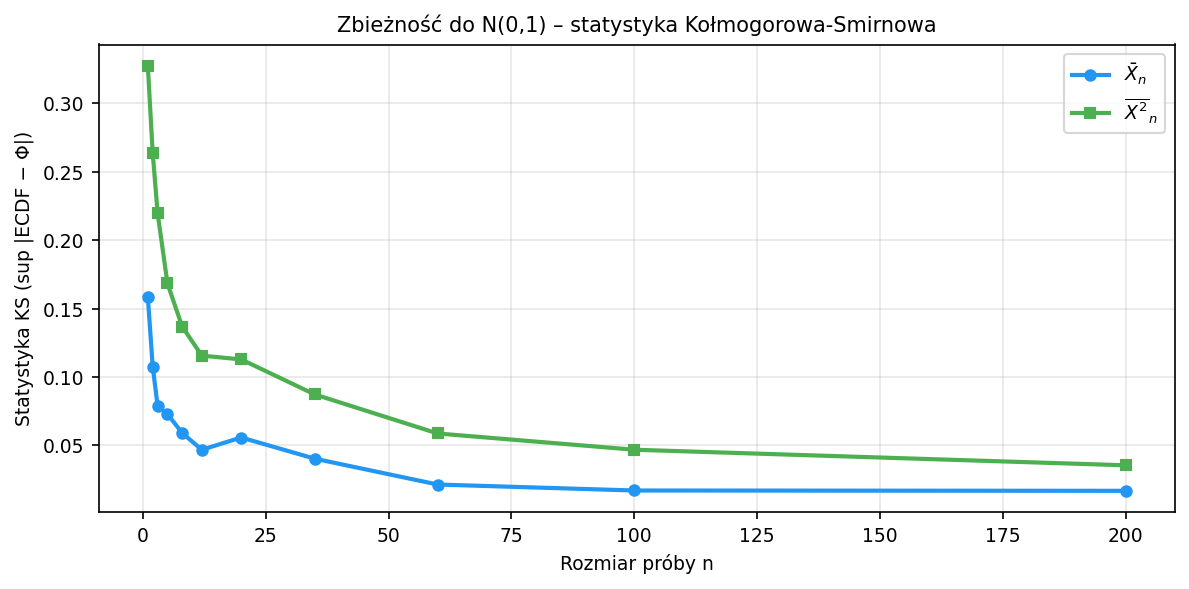

In [12]:
ns_fine = [1, 2, 3, 5, 8, 12, 20, 35, 60, 100, 200]
ks_xbar, ks_xsq = [], []

for n in ns_fine:
    xbar, xbar_sq = simulate_means(n, n_sim=3000)

    z1 = standardize(xbar, TRUE_MEAN, TRUE_VAR, n)
    z2 = standardize(xbar_sq, TRUE_MEAN_X2, TRUE_VAR_X2, n)

    ks_xbar.append(stats.kstest(z1, 'norm').statistic)
    ks_xsq.append(stats.kstest(z2, 'norm').statistic)

fig5, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

ax.plot(ns_fine, ks_xbar, 'o-', color=COLORS[0], lw=2, ms=5, label=r"$\bar{X}_n$")
ax.plot(ns_fine, ks_xsq,  's-', color=COLORS[1], lw=2, ms=5, label=r"$\overline{X^2}_n$")

ax.set_xlabel("Rozmiar próby n")
ax.set_ylabel("Statystyka KS (sup |ECDF − Φ|)")
ax.set_title("Zbieżność do N(0,1) – statystyka Kołmogorowa-Smirnowa")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
fig5.savefig(IMAGES_DIR / "fig5_ks_convergence.pdf", bbox_inches='tight')
plt.close(fig5)